# French WinoWhat Replication: Model Evaluation on Original and Paraphrased French Wino data.

In [1]:
# Install required libraries for the experiment:
# transformers (model loading), accelerate (efficient inference),
# sentencepiece (tokenization support), pandas (data handling), tqdm (progress bars)
!pip -q install transformers accelerate sentencepiece pandas tqdm

In [2]:
#import
import os
import math
import random
import numpy as np
import pandas as pd
import torch

from tqdm.auto import tqdm
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForMaskedLM
)
from google.colab import drive, files

# =========================
# 1. Reproducibility
# =========================
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(0)

In [3]:
# =========================
# 2. Mount Drive and load data
# =========================
drive.mount('/content/drive')

csv_path = "/content/drive/MyDrive/Thesis_2025/new/french_wino_with_paraphrases.csv"
df = pd.read_csv(csv_path)

print("Raw rows:", len(df))
print(df.head())

Mounted at /content/drive
Raw rows: 200
   id                                           sentence  \
0   1  La coupe n'entre pas dans la valise marron, ca...   
1   2  Paul a essayé de joindre Georges sur son télép...   
2   3  L'avocat a posé une question au témoin, mais _...   
3   4  Nicolas n'a pas pu soulever son fils car _ éta...   
4   5  Les lycéens harcelaient les collégiens, donc o...   

                                paraphrased_sentence         option1  \
0  Impossible de faire entrer la coupe dans la va...       la valise   
1  Paul a tenté d'appeler Georges sur son portabl...            Paul   
2  Après avoir interrogé le témoin, l’avocat s’es...        l'avocat   
3  Comme _ était trop faible, Nicolas n’a pas réu...         Nicolas   
4  À cause du harcèlement envers les collégiens, ...  les collégiens   

       option2  answer  
0     la coupe       2  
1      Georges       1  
2    le témoin       1  
3     son fils       1  
4  les lycéens       2  


In [4]:
# =========================
# 3. Clean and validate data
# =========================
required_cols = ["id", "sentence", "paraphrased_sentence", "option1", "option2", "answer"]
df = df.dropna(subset=required_cols).copy()

for col in ["sentence", "paraphrased_sentence", "option1", "option2"]:
    df[col] = df[col].astype(str).str.strip()

df["answer"] = df["answer"].astype(int)

print("\nAfter cleaning:", len(df))
print("\nAnswer distribution:")
print(df["answer"].value_counts())

bad_original = (df["sentence"].str.count("_") != 1).sum()
bad_para = (df["paraphrased_sentence"].str.count("_") != 1).sum()

print(f"\nBad original rows (blank count != 1): {bad_original}")
print(f"Bad paraphrased rows (blank count != 1): {bad_para}")

if bad_original > 0 or bad_para > 0:
    print("\nDropping malformed rows...")
    df = df[
        (df["sentence"].str.count("_") == 1) &
        (df["paraphrased_sentence"].str.count("_") == 1)
    ].copy()

print("\nFinal rows used:", len(df))


After cleaning: 200

Answer distribution:
answer
2    108
1     92
Name: count, dtype: int64

Bad original rows (blank count != 1): 1
Bad paraphrased rows (blank count != 1): 0

Dropping malformed rows...

Final rows used: 199


In [5]:
# =========================
# 4. Helper functions
# =========================
def fill_blank(text, option):
    return text.replace("_", option)

def build_completed_sentences(df, text_column):
    data = df.copy()
    data["filled_1"] = data.apply(lambda x: fill_blank(x[text_column], x["option1"]), axis=1)
    data["filled_2"] = data.apply(lambda x: fill_blank(x[text_column], x["option2"]), axis=1)
    return data

def accuracy_ci(acc, n, z=1.96):
    se = math.sqrt(acc * (1 - acc) / n)
    return acc - z * se, acc + z * se

In [6]:
# =========================
# 5. Mistral / causal LM scorer
#    PARTIAL EVALUATION
# =========================
class CausalPartialScorer:
    def __init__(self, model_name):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)

        self.model = AutoModelForCausalLM.from_pretrained(
            model_name,
            torch_dtype=torch.float16 if self.device == "cuda" else torch.float32,
            device_map="auto" if self.device == "cuda" else None
        )
        self.model.eval()

        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

    @torch.no_grad()
    def score_option(self, sentence_with_blank, option):
        parts = sentence_with_blank.split("_")
        if len(parts) != 2:
            raise ValueError(f"Sentence must contain exactly one blank:\n{sentence_with_blank}")

        prefix = parts[0] + option
        suffix = parts[1]

        whole_text = prefix + suffix

        whole_enc = self.tokenizer.encode(whole_text, add_special_tokens=False)
        prefix_enc = self.tokenizer.encode(prefix, add_special_tokens=False)

        continuation_enc = whole_enc[len(prefix_enc):]

        # Need at least one continuation token
        if len(continuation_enc) == 0:
            return float("-inf")

        # Input excludes final token, because causal LM predicts next token
        inp = torch.tensor(whole_enc[:-1], dtype=torch.long, device=self.model.device)

        outputs = self.model(inp.unsqueeze(0))
        log_probs = torch.log_softmax(outputs.logits.squeeze(0), dim=-1)

        cont_len = len(continuation_enc)

        # Logits corresponding to continuation positions
        start_idx = len(prefix_enc) - 1
        end_idx = start_idx + cont_len
        logits_for_cont = log_probs[start_idx:end_idx]

        cont_toks = torch.tensor(continuation_enc, device=self.model.device)

        selected = torch.gather(
            logits_for_cont, 1, cont_toks.unsqueeze(-1)
        ).squeeze(-1)

        return float(selected.sum())

In [7]:
# =========================
# 6. CamemBERT / masked LM scorer
#    PSEUDO-LOG-LIKELIHOOD
# =========================
class MaskedLMScorer:
    def __init__(self, model_name):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModelForMaskedLM.from_pretrained(model_name).to(self.device)
        self.model.eval()

    @torch.no_grad()
    def score(self, text):
        enc = self.tokenizer(text, return_tensors="pt", truncation=True)
        input_ids = enc["input_ids"].to(self.device)
        attention_mask = enc["attention_mask"].to(self.device)

        seq_len = input_ids.size(1)
        total_log_prob = 0.0

        # skip special tokens
        for i in range(1, seq_len - 1):
            original_token_id = input_ids[0, i].item()

            masked_input = input_ids.clone()
            masked_input[0, i] = self.tokenizer.mask_token_id

            outputs = self.model(input_ids=masked_input, attention_mask=attention_mask)
            logits = outputs.logits[0, i]
            log_probs = torch.log_softmax(logits, dim=-1)

            total_log_prob += log_probs[original_token_id].item()

        return total_log_prob


In [8]:
# =========================
# 7. Evaluation functions
# =========================
def evaluate_dataset_causal_partial(df, text_column, scorer):
    data = df.copy()

    predictions = []
    score1_list = []
    score2_list = []

    for _, row in tqdm(data.iterrows(), total=len(data), desc=f"Evaluating {text_column}"):
        s1 = scorer.score_option(row[text_column], row["option1"])
        s2 = scorer.score_option(row[text_column], row["option2"])

        pred = 1 if s1 > s2 else 2

        predictions.append(pred)
        score1_list.append(s1)
        score2_list.append(s2)

    data["pred"] = predictions
    data["score1"] = score1_list
    data["score2"] = score2_list
    data["correct"] = (data["pred"] == data["answer"]).astype(int)

    accuracy = data["correct"].mean()
    return accuracy, data

def evaluate_dataset_mlm(df, text_column, scorer):
    data = build_completed_sentences(df, text_column)

    predictions = []
    score1_list = []
    score2_list = []

    for _, row in tqdm(data.iterrows(), total=len(data), desc=f"Evaluating {text_column}"):
        s1 = scorer.score(row["filled_1"])
        s2 = scorer.score(row["filled_2"])

        pred = 1 if s1 > s2 else 2

        predictions.append(pred)
        score1_list.append(s1)
        score2_list.append(s2)

    data["pred"] = predictions
    data["score1"] = score1_list
    data["score2"] = score2_list
    data["correct"] = (data["pred"] == data["answer"]).astype(int)

    accuracy = data["correct"].mean()
    return accuracy, data


In [9]:
# =========================
# 8. Baselines
# =========================
random_baseline = 0.50
always_option1_baseline = (df["answer"] == 1).mean()

print("\nBaselines")
print(f"Random baseline:       {random_baseline:.4f}")
print(f"Always option1:        {always_option1_baseline:.4f}")

# =========================
# 9. Output folder
# =========================
output_dir = "/content/wino_results"
os.makedirs(output_dir, exist_ok=True)

summary_rows = []


Baselines
Random baseline:       0.5000
Always option1:        0.4623


## Mistral

In [10]:
# =========================
# 10. Mistral
# =========================
print("\n=========================")
print("Running Mistral")
print("=========================")

mistral_model_name = "mistralai/Mistral-7B-v0.1"
mistral_scorer = CausalPartialScorer(mistral_model_name)

orig_acc_mistral, orig_results_mistral = evaluate_dataset_causal_partial(df, "sentence", mistral_scorer)
para_acc_mistral, para_results_mistral = evaluate_dataset_causal_partial(df, "paraphrased_sentence", mistral_scorer)

orig_ci_mistral = accuracy_ci(orig_acc_mistral, len(df))
para_ci_mistral = accuracy_ci(para_acc_mistral, len(df))

print(f"Original accuracy:     {orig_acc_mistral:.4f}")
print(f"Paraphrased accuracy:  {para_acc_mistral:.4f}")
print(f"Drop:                  {orig_acc_mistral - para_acc_mistral:.4f}")
print(f"Original 95% CI:       ({orig_ci_mistral[0]:.4f}, {orig_ci_mistral[1]:.4f})")
print(f"Paraphrased 95% CI:    ({para_ci_mistral[0]:.4f}, {para_ci_mistral[1]:.4f})")

orig_path = os.path.join(output_dir, "results_original_mistral.csv")
para_path = os.path.join(output_dir, "results_paraphrased_mistral.csv")

orig_results_mistral.to_csv(orig_path, index=False)
para_results_mistral.to_csv(para_path, index=False)

wrong_orig = orig_results_mistral[orig_results_mistral["correct"] == 0][
    ["id", "sentence", "option1", "option2", "answer", "pred", "score1", "score2"]
]
wrong_para = para_results_mistral[para_results_mistral["correct"] == 0][
    ["id", "paraphrased_sentence", "option1", "option2", "answer", "pred", "score1", "score2"]
]

wrong_orig_path = os.path.join(output_dir, "wrong_original_mistral.csv")
wrong_para_path = os.path.join(output_dir, "wrong_paraphrased_mistral.csv")

wrong_orig.to_csv(wrong_orig_path, index=False)
wrong_para.to_csv(wrong_para_path, index=False)

summary_rows.append({
    "model": "mistral-7b-v0.1",
    "scoring": "causal_partial_evaluation",
    "n": len(df),
    "original_accuracy": orig_acc_mistral,
    "paraphrased_accuracy": para_acc_mistral,
    "drop": orig_acc_mistral - para_acc_mistral,
    "original_ci_low": orig_ci_mistral[0],
    "original_ci_high": orig_ci_mistral[1],
    "paraphrased_ci_low": para_ci_mistral[0],
    "paraphrased_ci_high": para_ci_mistral[1]
})


Running Mistral


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/996 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

Evaluating sentence:   0%|          | 0/199 [00:00<?, ?it/s]

Evaluating paraphrased_sentence:   0%|          | 0/199 [00:00<?, ?it/s]

Original accuracy:     0.7387
Paraphrased accuracy:  0.6281
Drop:                  0.1106
Original 95% CI:       (0.6777, 0.7997)
Paraphrased 95% CI:    (0.5610, 0.6953)


In [11]:
# Free memory before loading CamemBERT
del mistral_scorer
torch.cuda.empty_cache()

## CamemBert

In [12]:
# =========================
# 11. CamemBERT
# =========================
print("\n=========================")
print("Running CamemBERT")
print("=========================")

camembert_model_name = "camembert-base"
camembert_scorer = MaskedLMScorer(camembert_model_name)

orig_acc_camembert, orig_results_camembert = evaluate_dataset_mlm(df, "sentence", camembert_scorer)
para_acc_camembert, para_results_camembert = evaluate_dataset_mlm(df, "paraphrased_sentence", camembert_scorer)

orig_ci_camembert = accuracy_ci(orig_acc_camembert, len(df))
para_ci_camembert = accuracy_ci(para_acc_camembert, len(df))

print(f"Original accuracy:     {orig_acc_camembert:.4f}")
print(f"Paraphrased accuracy:  {para_acc_camembert:.4f}")
print(f"Drop:                  {orig_acc_camembert - para_acc_camembert:.4f}")
print(f"Original 95% CI:       ({orig_ci_camembert[0]:.4f}, {orig_ci_camembert[1]:.4f})")
print(f"Paraphrased 95% CI:    ({para_ci_camembert[0]:.4f}, {para_ci_camembert[1]:.4f})")

orig_path = os.path.join(output_dir, "results_original_camembert.csv")
para_path = os.path.join(output_dir, "results_paraphrased_camembert.csv")

orig_results_camembert.to_csv(orig_path, index=False)
para_results_camembert.to_csv(para_path, index=False)

wrong_orig = orig_results_camembert[orig_results_camembert["correct"] == 0][
    ["id", "sentence", "option1", "option2", "answer", "pred", "score1", "score2"]
]
wrong_para = para_results_camembert[para_results_camembert["correct"] == 0][
    ["id", "paraphrased_sentence", "option1", "option2", "answer", "pred", "score1", "score2"]
]

wrong_orig_path = os.path.join(output_dir, "wrong_original_camembert.csv")
wrong_para_path = os.path.join(output_dir, "wrong_paraphrased_camembert.csv")

wrong_orig.to_csv(wrong_orig_path, index=False)
wrong_para.to_csv(wrong_para_path, index=False)

summary_rows.append({
    "model": "camembert-base",
    "scoring": "masked_lm_pseudo_log_likelihood",
    "n": len(df),
    "original_accuracy": orig_acc_camembert,
    "paraphrased_accuracy": para_acc_camembert,
    "drop": orig_acc_camembert - para_acc_camembert,
    "original_ci_low": orig_ci_camembert[0],
    "original_ci_high": orig_ci_camembert[1],
    "paraphrased_ci_low": para_ci_camembert[0],
    "paraphrased_ci_high": para_ci_camembert[1]
})


Running CamemBERT


config.json:   0%|          | 0.00/508 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/811k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

CamembertForMaskedLM LOAD REPORT from: camembert-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.decoder.bias        | MISSING    | 
lm_head.decoder.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Evaluating sentence:   0%|          | 0/199 [00:00<?, ?it/s]

Evaluating paraphrased_sentence:   0%|          | 0/199 [00:00<?, ?it/s]

Original accuracy:     0.4874
Paraphrased accuracy:  0.4824
Drop:                  0.0050
Original 95% CI:       (0.4180, 0.5569)
Paraphrased 95% CI:    (0.4130, 0.5518)


In [13]:
# =========================
# 12. Save summary
# =========================
summary_df = pd.DataFrame(summary_rows)
summary_path = os.path.join(output_dir, "summary_results.csv")
summary_df.to_csv(summary_path, index=False)

print("\nSummary:")
print(summary_df)



Summary:
             model                          scoring    n  original_accuracy  \
0  mistral-7b-v0.1        causal_partial_evaluation  199           0.738693   
1   camembert-base  masked_lm_pseudo_log_likelihood  199           0.487437   

   paraphrased_accuracy      drop  original_ci_low  original_ci_high  \
0              0.628141  0.110553         0.677650          0.799737   
1              0.482412  0.005025         0.417989          0.556886   

   paraphrased_ci_low  paraphrased_ci_high  
0            0.560991             0.695291  
1            0.412985             0.551839  


In [14]:
# =========================
# 13. Download files
# =========================
download_files = [
    "results_original_mistral.csv",
    "results_paraphrased_mistral.csv",
    "wrong_original_mistral.csv",
    "wrong_paraphrased_mistral.csv",
    "results_original_camembert.csv",
    "results_paraphrased_camembert.csv",
    "wrong_original_camembert.csv",
    "wrong_paraphrased_camembert.csv",
    "summary_results.csv",
]

for fname in download_files:
    files.download(os.path.join(output_dir, fname))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
# =========================
# 14. McNemar
# =========================
import numpy as np
from statsmodels.stats.contingency_tables import mcnemar

def mcnemar_test(predictions_a, predictions_b, true_labels):
    correct_a = (predictions_a == true_labels).astype(int)
    correct_b = (predictions_b == true_labels).astype(int)

    contingency_table = np.zeros((2, 2), dtype=int)

    for ca, cb in zip(correct_a, correct_b):
        contingency_table[ca, cb] += 1

    result = mcnemar(contingency_table, exact=True)

    b = contingency_table[0, 1]  # A incorrect, B correct
    c = contingency_table[1, 0]  # A correct, B incorrect
    effect_size = abs(b - c) / (b + c) if (b + c) > 0 else 0.0

    return contingency_table, result.pvalue, effect_size

def run_mcnemar_condition_comparison(orig_results, para_results, model_name):
    orig_sorted = orig_results.sort_values("id").reset_index(drop=True)
    para_sorted = para_results.sort_values("id").reset_index(drop=True)

    table, p_value, effect_size = mcnemar_test(
        orig_sorted["pred"],
        para_sorted["pred"],
        orig_sorted["answer"]
    )

    print(f"\nMcNemar test for {model_name}: Original vs Paraphrased")
    print("Contingency table:")
    print(table)
    print(f"p-value: {p_value:.6f}")
    print(f"effect size: {effect_size:.4f}")

    return table, p_value, effect_size

In [16]:
# Mistral original vs paraphrased
run_mcnemar_condition_comparison(
    orig_results_mistral,
    para_results_mistral,
    "Mistral-7B"
)


McNemar test for Mistral-7B: Original vs Paraphrased
Contingency table:
[[ 27  25]
 [ 47 100]]
p-value: 0.012775
effect size: 0.3056


(array([[ 27,  25],
        [ 47, 100]]),
 np.float64(0.012774595538064901),
 np.float64(0.3055555555555556))

In [17]:
# CamemBERT original vs paraphrased
run_mcnemar_condition_comparison(
    orig_results_camembert,
    para_results_camembert,
    "CamemBERT"
)


McNemar test for CamemBERT: Original vs Paraphrased
Contingency table:
[[87 15]
 [16 81]]
p-value: 1.000000
effect size: 0.0323


(array([[87, 15],
        [16, 81]]),
 np.float64(1.0),
 np.float64(0.03225806451612903))

## Visuals

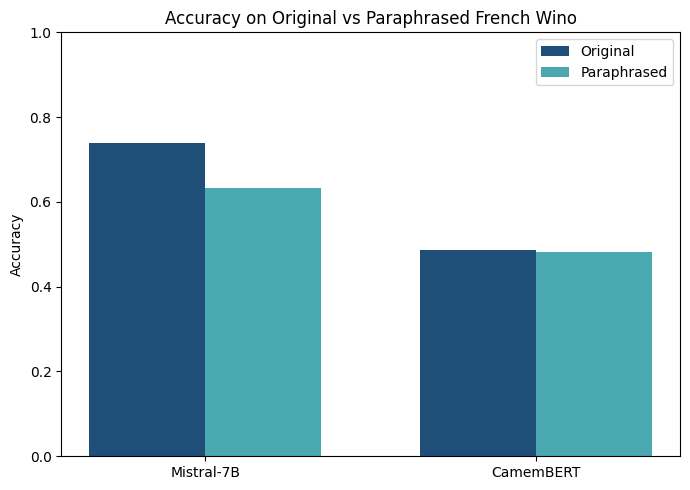

In [29]:
# Main accuracy comparison bar chart
import matplotlib.pyplot as plt
import numpy as np

models = ["Mistral-7B", "CamemBERT"]

original = [0.738693, 0.487437]
paraphrased = [0.633166, 0.482412]

x = np.arange(len(models))
width = 0.35

dark_blue = "#1f4e79"
teal = "#4aa8b0"

plt.figure(figsize=(7,5))

plt.bar(x - width/2, original, width, label="Original", color=dark_blue)
plt.bar(x + width/2, paraphrased, width, label="Paraphrased", color=teal)

plt.xticks(x, models)
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.title("Accuracy on Original vs Paraphrased French Wino")

plt.legend()
plt.tight_layout()

plt.savefig("accuracy_comparison.png", dpi=300)
plt.show()

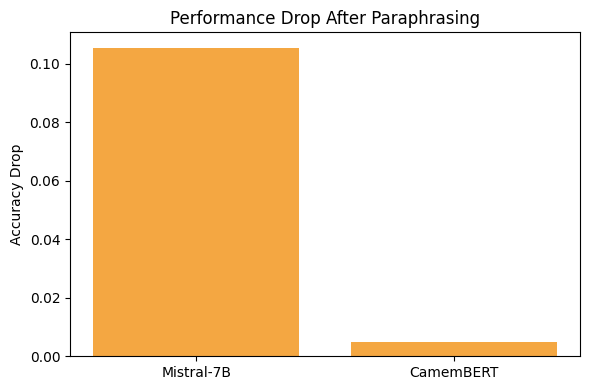

In [28]:
# Accuracy drop
import matplotlib.pyplot as plt

models = ["Mistral-7B", "CamemBERT"]
drops = [0.738693 - 0.633166, 0.487437 - 0.482412]

orange = "#f4a742"

plt.figure(figsize=(6,4))
plt.bar(models, drops, color=orange)

plt.ylabel("Accuracy Drop")
plt.title("Performance Drop After Paraphrasing")

plt.tight_layout()
plt.savefig("accuracy_drop.png", dpi=300)

plt.show()

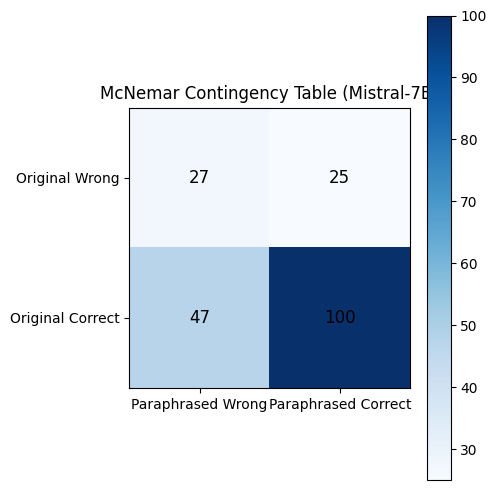

In [31]:
# McNemar heatmap (Mistral)
import matplotlib.pyplot as plt
import numpy as np

table = np.array([[27,25],
                  [47,100]])

plt.figure(figsize=(5,5))

plt.imshow(table, cmap="Blues")

plt.xticks([0,1], ["Paraphrased Wrong", "Paraphrased Correct"])
plt.yticks([0,1], ["Original Wrong", "Original Correct"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, table[i,j], ha="center", va="center", fontsize=12)

plt.title("McNemar Contingency Table (Mistral-7B)")
plt.colorbar()

plt.tight_layout()
plt.savefig("mcnemar_mistral.png", dpi=300)

plt.show()

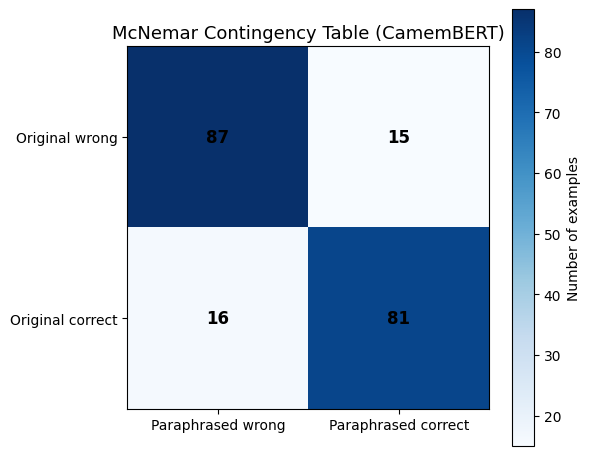

In [33]:
# McNemar heatmap (CamemBert)
import matplotlib.pyplot as plt
import numpy as np

camembert_table = np.array([[87, 15],
                            [16, 81]])

fig, ax = plt.subplots(figsize=(6,5))

# use a clean blue palette
im = ax.imshow(camembert_table, cmap="Blues")

ax.set_xticks([0,1])
ax.set_yticks([0,1])

ax.set_xticklabels(["Paraphrased wrong", "Paraphrased correct"])
ax.set_yticklabels(["Original wrong", "Original correct"])

# add numbers inside cells
for i in range(camembert_table.shape[0]):
    for j in range(camembert_table.shape[1]):
        ax.text(j, i, camembert_table[i, j],
                ha="center",
                va="center",
                fontsize=12,
                fontweight="bold")

# title
ax.set_title("McNemar Contingency Table (CamemBERT)", fontsize=13)

# add colorbar
cbar = plt.colorbar(im)
cbar.ax.set_ylabel("Number of examples", rotation=90)

plt.tight_layout()

plt.savefig("graph_camembert_mcnemar.png", dpi=300, bbox_inches="tight")

plt.show()

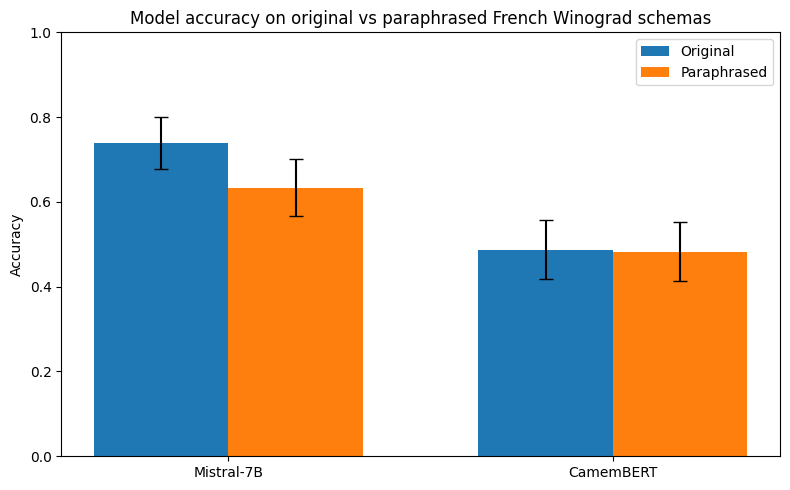

In [34]:
# With confidence intervals
import matplotlib.pyplot as plt
import numpy as np

models = ["Mistral-7B", "CamemBERT"]

original = [0.738693, 0.487437]
paraphrased = [0.633166, 0.482412]

original_ci_low = [0.677650, 0.417989]
original_ci_high = [0.799737, 0.556886]

paraphrased_ci_low = [0.566205, 0.412985]
paraphrased_ci_high = [0.700127, 0.551839]

original_err = [
    [original[i] - original_ci_low[i] for i in range(len(models))],
    [original_ci_high[i] - original[i] for i in range(len(models))]
]

paraphrased_err = [
    [paraphrased[i] - paraphrased_ci_low[i] for i in range(len(models))],
    [paraphrased_ci_high[i] - paraphrased[i] for i in range(len(models))]
]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, original, width, yerr=original_err, capsize=5, label="Original")
plt.bar(x + width/2, paraphrased, width, yerr=paraphrased_err, capsize=5, label="Paraphrased")

plt.xticks(x, models)
plt.ylabel("Accuracy")
plt.ylim(0, 1.0)
plt.title("Model accuracy on original vs paraphrased French Winograd schemas")
plt.legend()
plt.tight_layout()
plt.savefig("graph_1_accuracy_comparison_with_ci.png", dpi=300, bbox_inches="tight")
plt.show()